# CODEALPHA DATA SCIENCE INTERNSHIP
# TASK; Sales Prediction - Multi-channel advertising impact
# Intern: ALQAMA NAJAM


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

In [4]:
#  style
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (15, 6)
 
print("=" * 80)
print("SALES PREDICTION - MACHINE LEARNING PROJECT")
print("=" * 80)

SALES PREDICTION - MACHINE LEARNING PROJECT


In [64]:
# =====LOADED DATA =====
df = pd.read_csv("D:\Advertising.csv")
print(f"\n Dataset loaded: {df.shape}")
print("\nFirst few rows:")
print(df.head())
print("\nData Info:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())


 Dataset loaded: (200, 5)

First few rows:
   Unnamed: 0     TV  Radio  Newspaper  Sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB
None

Basic Statistics:
       Unnamed: 0          TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000  200.000000
mean   100.500000  147.042500   23.264000   30.554000   14.022500
std  

In [8]:
# ===== EXPLORATORY DATA ANALYSIS =====
print("\n" + "=" * 80)
print("EXPLORATORY DATA ANALYSIS")
print("=" * 80)
 
print("\nSales Statistics:")
print(df['Sales'].describe())


EXPLORATORY DATA ANALYSIS

Sales Statistics:
count    200.000000
mean      14.022500
std        5.217457
min        1.600000
25%       10.375000
50%       12.900000
75%       17.400000
max       27.000000
Name: Sales, dtype: float64



 Saved: 01_sales_exploration.png


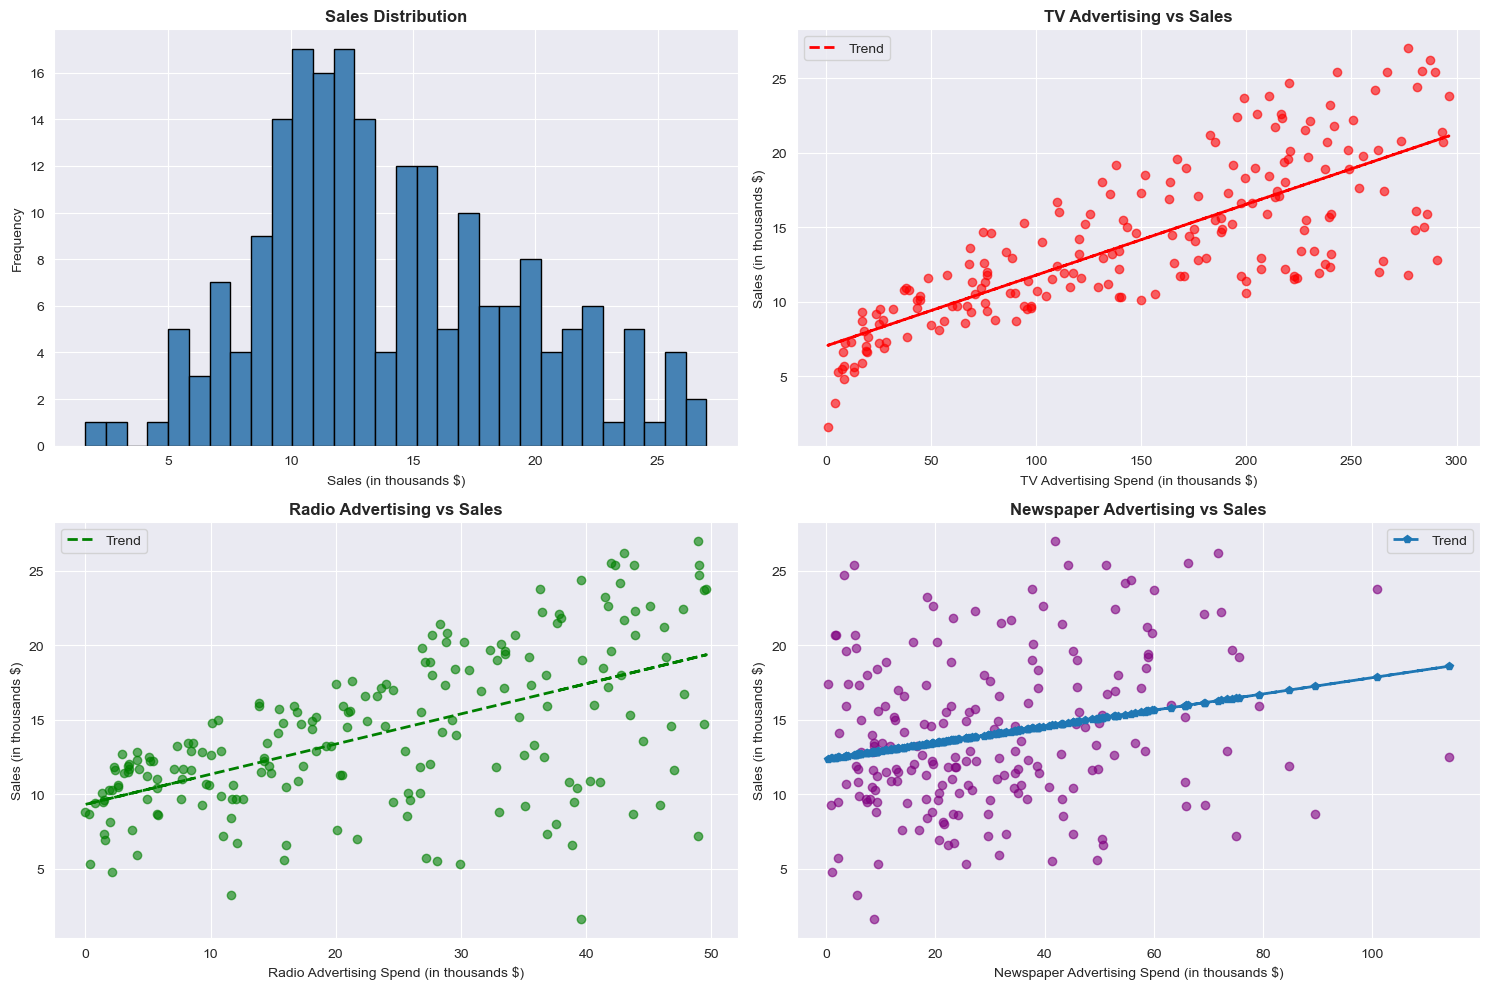

In [14]:
# visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
# Sales Distribution
axes[0, 0].hist(df['Sales'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Sales Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Sales (in thousands $)')
axes[0, 0].set_ylabel('Frequency')
#  TV Advertising vs Sales
axes[0, 1].scatter(df['TV'], df['Sales'], alpha=0.6, color='red')
axes[0, 1].set_title('TV Advertising vs Sales', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('TV Advertising Spend (in thousands $)')
axes[0, 1].set_ylabel('Sales (in thousands $)')
# trend line
z = np.polyfit(df['TV'], df['Sales'], 1)
p = np.poly1d(z)
axes[0, 1].plot(df['TV'], p(df['TV']), "r--", linewidth=2, label='Trend')
axes[0, 1].legend()
# 3. Radio Advertising vs Sales
axes[1, 0].scatter(df['Radio'], df['Sales'], alpha=0.6, color='green')
axes[1, 0].set_title('Radio Advertising vs Sales', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Radio Advertising Spend (in thousands $)')
axes[1, 0].set_ylabel('Sales (in thousands $)')
# trend line
z = np.polyfit(df['Radio'], df['Sales'], 1)
p = np.poly1d(z)
axes[1, 0].plot(df['Radio'], p(df['Radio']), "g--", linewidth=2, label='Trend')
axes[1, 0].legend()
# Newspaper Advertising vs Sales
axes[1, 1].scatter(df['Newspaper'], df['Sales'], alpha=0.6, color='purple')
axes[1, 1].set_title('Newspaper Advertising vs Sales', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Newspaper Advertising Spend (in thousands $)')
axes[1, 1].set_ylabel('Sales (in thousands $)')
# trend line
z = np.polyfit(df['Newspaper'], df['Sales'], 1)
p = np.poly1d(z)
axes[1, 1].plot(df['Newspaper'], p(df['Newspaper']), "p--", linewidth=2, label='Trend')
axes[1, 1].legend()
 
plt.tight_layout()
plt.savefig('01_sales_exploration.png', dpi=300, bbox_inches='tight')
print("\n Saved: 01_sales_exploration.png")
plt.show()

In [15]:
# ===== DATA PREPROCESSING =====
print("\n" + "=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)
 
df_clean = df.copy()


DATA PREPROCESSING


In [16]:
# Droping index column if it exists
if '' in df_clean.columns:
    df_clean = df_clean.drop('', axis=1)

In [53]:
#missing values
missing_before = df_clean.isnull().sum().sum()
df_clean = df_clean.dropna()
missing_after = df_clean.isnull().sum().sum()
print(f" yes! Removed {missing_before - missing_after} rows with missing values")
print(f" yes! Clean dataset shape: {df_clean.shape}")

 yes! Removed 0 rows with missing values
 yes! Clean dataset shape: (200, 9)


In [20]:
# ===== CORRELATION ANALYSIS =====
print("\n" + "=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)
 
correlation_matrix = df_clean.corr()
print("\nCorrelation Matrix:")
print(correlation_matrix)


CORRELATION ANALYSIS

Correlation Matrix:
            Unnamed: 0        TV     Radio  Newspaper     Sales
Unnamed: 0    1.000000  0.017715 -0.110680  -0.154944 -0.051616
TV            0.017715  1.000000  0.054809   0.056648  0.782224
Radio        -0.110680  0.054809  1.000000   0.354104  0.576223
Newspaper    -0.154944  0.056648  0.354104   1.000000  0.228299
Sales        -0.051616  0.782224  0.576223   0.228299  1.000000



 Saved: 02_sales_correlation.png


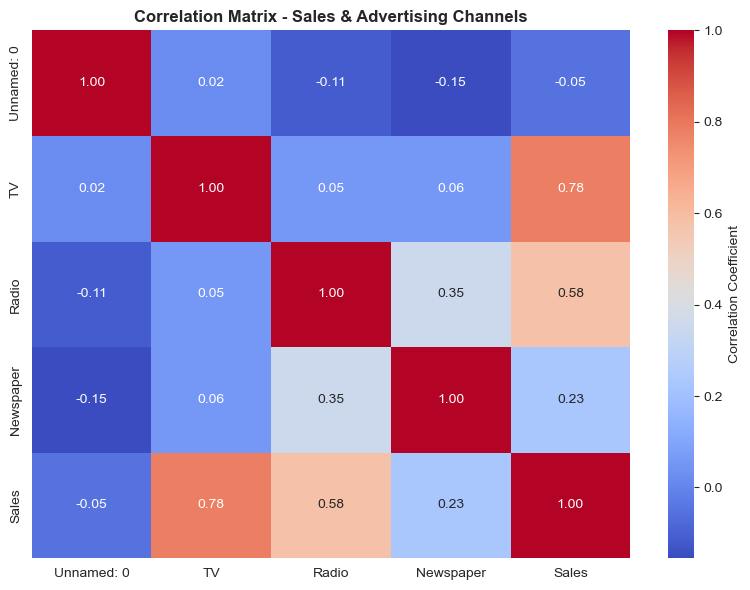

In [21]:
# Visualizing correlation
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            ax=ax, cbar_kws={'label': 'Correlation Coefficient'})
ax.set_title('Correlation Matrix - Sales & Advertising Channels', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('02_sales_correlation.png', dpi=300, bbox_inches='tight')
print("\n Saved: 02_sales_correlation.png")
plt.show()

In [22]:
# ===== FEATURE ENGINEERING =====
print("\n" + "=" * 80)
print("FEATURE ENGINEERING")
print("=" * 80)


FEATURE ENGINEERING


In [65]:
# interaction features
df_clean['TV_Radio_Interaction'] = df_clean['TV'] * df_clean['Radio']
print(f" Created TV-Radio interaction feature")
 
df_clean['TV_Newspaper_Interaction'] = df_clean['TV'] * df_clean['Newspaper']
print(f" Created TV-Newspaper interaction feature")
 
df_clean['Radio_Newspaper_Interaction'] = df_clean['Radio'] * df_clean['Newspaper']
print(f" Created Radio-Newspaper interaction feature")
 
df_clean['Total_Advertising'] = df_clean['TV'] + df_clean['Radio'] + df_clean['Newspaper']
print(f" Created total advertising feature")
 
print(f"\n Total features created: {len(df_clean.columns)}")

 Created TV-Radio interaction feature
 Created TV-Newspaper interaction feature
 Created Radio-Newspaper interaction feature
 Created total advertising feature

 Total features created: 9


In [66]:
# ===== DATA FOR MODELS =====
X = df_clean.drop('Sales', axis=1)
y = df_clean['Sales']
 
print(f"\n Features: {list(X.columns)}")
print(f" Target: Sales")


 Features: ['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'TV_Radio_Interaction', 'TV_Newspaper_Interaction', 'Radio_Newspaper_Interaction', 'Total_Advertising']
 Target: Sales


In [56]:
# Spliting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\n Training set: {X_train.shape[0]} samples")
print(f" Testing set: {X_test.shape[0]} samples")


 Training set: 160 samples
 Testing set: 40 samples


In [67]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f" Features standardized")

 Features standardized


In [28]:
# =====  TRAINING MODELS =====
print("\n" + "=" * 80)
print("TRAINING SALES PREDICTION MODELS")
print("=" * 80)


TRAINING SALES PREDICTION MODELS


In [57]:
# Model 1: Linear Regression
print("\nTraining Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)
lr_r2 = r2_score(y_test, lr_pred)
lr_mae = mean_absolute_error(y_test, lr_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))
print(f"Linear Regression - R² = {lr_r2:.4f}, MAE = {lr_mae:.4f}, RMSE = {lr_rmse:.4f}")


Training Linear Regression...
Linear Regression - R² = 0.9751, MAE = 0.6679, RMSE = 0.8869


In [58]:
# Model 2: Random Forest
print("Training Random Forest Regressor...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42)
rf_model.fit(X_train_scaled, y_train)
rf_pred = rf_model.predict(X_test_scaled)
rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
print(f" Random Forest - R² = {rf_r2:.4f}, MAE = {rf_mae:.4f}, RMSE = {rf_rmse:.4f}")

Training Random Forest Regressor...
 Random Forest - R² = 0.9877, MAE = 0.4830, RMSE = 0.6236


In [59]:
# Model 3: Gradient Boosting
print("Training Gradient Boosting Regressor...")
gb_model = GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42)
gb_model.fit(X_train_scaled, y_train)
gb_pred = gb_model.predict(X_test_scaled)
gb_r2 = r2_score(y_test, gb_pred)
gb_mae = mean_absolute_error(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
print(f"Gradient Boosting - R² = {gb_r2:.4f}, MAE = {gb_mae:.4f}, RMSE = {gb_rmse:.4f}")

Training Gradient Boosting Regressor...
Gradient Boosting - R² = 0.9826, MAE = 0.4964, RMSE = 0.7409


In [68]:
# =====  MODEL COMPARISON =====
print("\n" + "=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)
 
models_performance = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting'],
    'R² Score': [lr_r2, rf_r2, gb_r2],
    'MAE': [lr_mae, rf_mae, gb_mae],
    'RMSE': [lr_rmse, rf_rmse, gb_rmse]
})
 
print("\n")
print(models_performance.to_string(index=False))
 
best_model_idx = models_performance['R² Score'].idxmax()
best_model_name = models_performance.loc[best_model_idx, 'Model']
best_r2 = models_performance.loc[best_model_idx, 'R² Score']
print(f"\n Best Model: {best_model_name} (R² = {best_r2:.4f})")


MODEL PERFORMANCE COMPARISON


            Model  R² Score      MAE     RMSE
Linear Regression  0.975077 0.667908 0.886936
    Random Forest  0.987679 0.483050 0.623607
Gradient Boosting  0.982609 0.496406 0.740884

 Best Model: Random Forest (R² = 0.9877)



 Saved: 03_sales_predictions_comparison.png


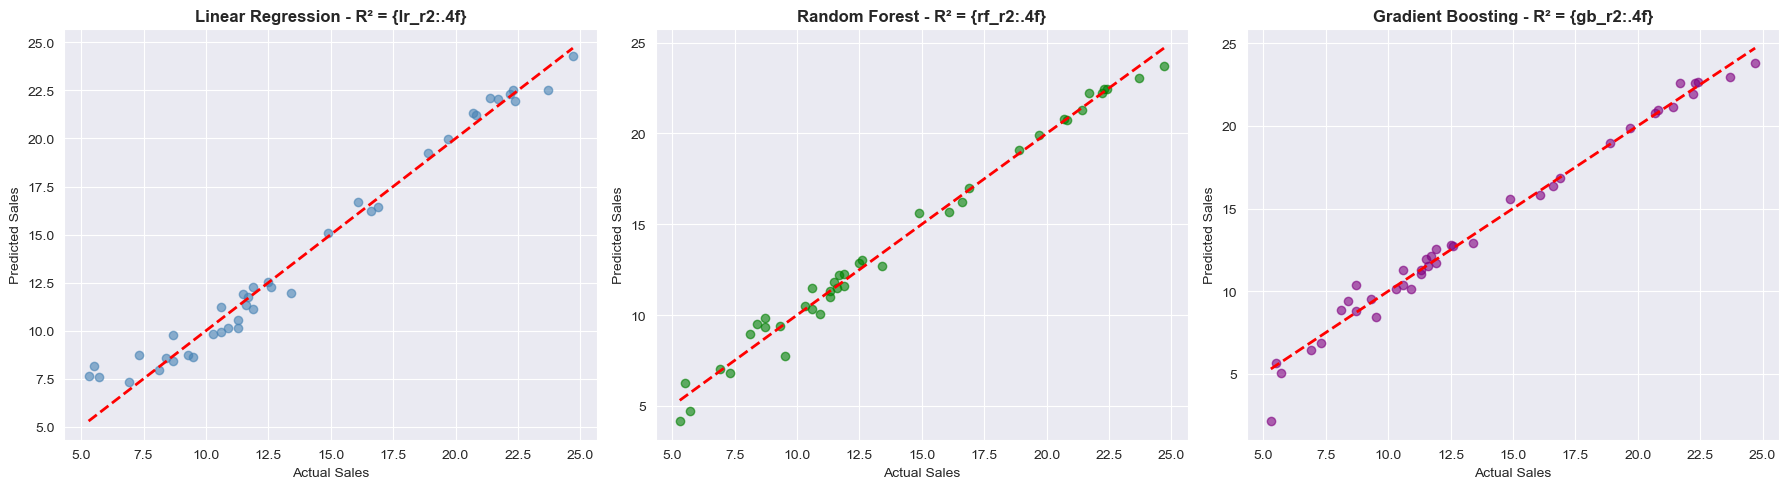

In [45]:
# =====  VISUALIZATION OF PREDICTIONS =====
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
# Linear Regression
axes[0].scatter(y_test, lr_pred, alpha=0.6, color='steelblue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('Actual Sales')
axes[0].set_ylabel('Predicted Sales')
axes[0].set_title('Linear Regression - R² = {lr_r2:.4f}', fontsize=12, fontweight='bold')
 
# Random Forest
axes[1].scatter(y_test, rf_pred, alpha=0.6, color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_xlabel('Actual Sales')
axes[1].set_ylabel('Predicted Sales')
axes[1].set_title('Random Forest - R² = {rf_r2:.4f}', fontsize=12, fontweight='bold')
 
# Gradient Boosting
axes[2].scatter(y_test, gb_pred, alpha=0.6, color='purple')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_xlabel('Actual Sales')
axes[2].set_ylabel('Predicted Sales')
axes[2].set_title('Gradient Boosting - R² = {gb_r2:.4f}', fontsize=12, fontweight='bold')
 
plt.tight_layout()
plt.savefig('03_sales_predictions_comparison.png', dpi=300, bbox_inches='tight')
print("\n Saved: 03_sales_predictions_comparison.png")
plt.show()


FEATURE IMPORTANCE ANALYSIS

 Saved: 04_sales_feature_importance.png


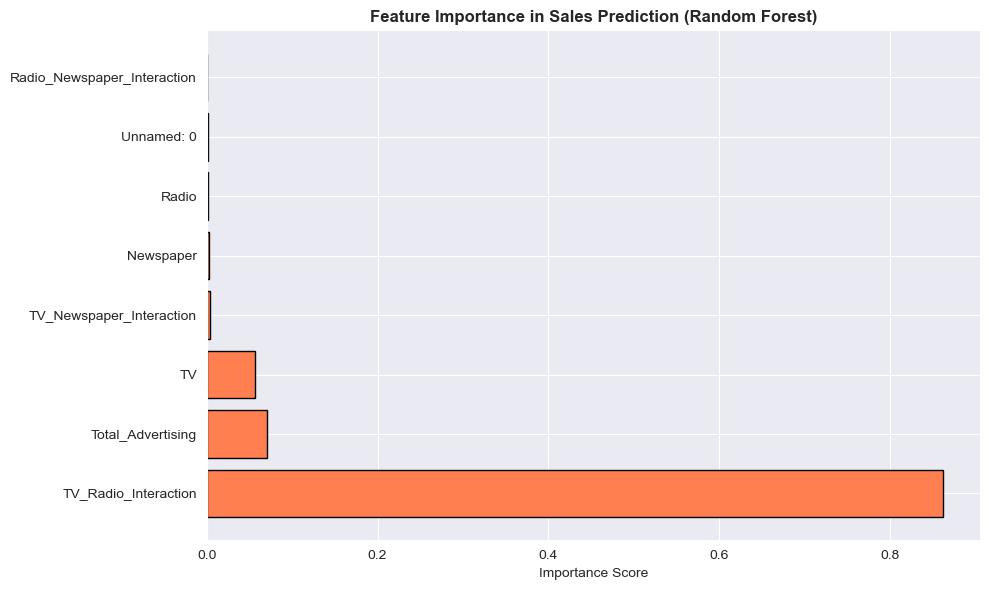

In [62]:
# =====FEATURE IMPORTANCE =====
print("\n" + "=" * 80)
print("FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)
 
fig, ax = plt.subplots(figsize=(10, 6))
feature_importance = rf_model.feature_importances_
feature_names = X.columns
top_indices = np.argsort(feature_importance)[::-1]
 
ax.barh(range(len(feature_names)), feature_importance[top_indices], color='coral', edgecolor='black')
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels([feature_names[i] for i in top_indices])
ax.set_xlabel('Importance Score')
ax.set_title('Feature Importance in Sales Prediction (Random Forest)', fontsize=12, fontweight='bold')
 
plt.tight_layout()
plt.savefig('04_sales_feature_importance.png', dpi=300, bbox_inches='tight')
print(f"\n Saved: 04_sales_feature_importance.png")
plt.show()

In [41]:
# ===== BUSINESS INSIGHTS =====
print("\n" + "=" * 80)
print("BUSINESS INSIGHTS & RECOMMENDATIONS")
print("=" * 80)
 
print(f"""
✓ KEY FINDINGS:
 
1. MODEL PERFORMANCE:
   • Best performing model: {best_model_name}
   • R² Score: {best_r2:.4f} (explains {best_r2*100:.1f}% of sales variance)
   • Average prediction error (MAE): {np.mean([lr_mae, rf_mae, gb_mae]):.4f}
 
2. ADVERTISING CHANNEL IMPACT (Correlation with Sales):
   • TV Advertising: {correlation_matrix.loc['TV', 'Sales']:.4f} (Strong)
   • Radio Advertising: {correlation_matrix.loc['Radio', 'Sales']:.4f} (Moderate)
   • Newspaper Advertising: {correlation_matrix.loc['Newspaper', 'Sales']:.4f} (Weak)
 
3. FEATURE IMPORTANCE RANKING:
""")
 
for idx, i in enumerate(top_indices[:5]):
    print(f"   {idx+1}. {feature_names[i]}: {feature_importance[i]:.4f}")
 
print(f"""
4. RECOMMENDATIONS:
    Prioritize TV advertising - strongest impact on sales
    Radio advertising has moderate positive effect
    Newspaper advertising shows minimal direct impact
    Consider synergistic effects between channels
    Use model to predict sales before launching campaigns
""")


BUSINESS INSIGHTS & RECOMMENDATIONS

✓ KEY FINDINGS:

1. MODEL PERFORMANCE:
   • Best performing model: Random Forest
   • R² Score: 0.9877 (explains 98.8% of sales variance)
   • Average prediction error (MAE): 0.5491

2. ADVERTISING CHANNEL IMPACT (Correlation with Sales):
   • TV Advertising: 0.7822 (Strong)
   • Radio Advertising: 0.5762 (Moderate)
   • Newspaper Advertising: 0.2283 (Weak)

3. FEATURE IMPORTANCE RANKING:

   1. TV_Radio_Interaction: 0.8619
   2. Total_Advertising: 0.0708
   3. TV: 0.0569
   4. TV_Newspaper_Interaction: 0.0038
   5. Newspaper: 0.0028

4. RECOMMENDATIONS:
    Prioritize TV advertising - strongest impact on sales
    Radio advertising has moderate positive effect
    Newspaper advertising shows minimal direct impact
    Consider synergistic effects between channels
    Use model to predict sales before launching campaigns



In [42]:
# =====SUMMARY =====
print("\n" + "=" * 80)
print("PROJECT SUMMARY")
print("=" * 80)


PROJECT SUMMARY


In [63]:
print("\n" + "=" * 80)
print("PROJECT SUMMARY")
print("=" * 80)
print("Dataset: Advertising Sales Dataset ({df_clean.shape[0]} records)")
print(" Features: {len(X.columns)} (TV, Radio, Newspaper + interactions)")
print(" Models Trained: 3 (Linear Regression, Random Forest, Gradient Boosting)")
print(f" Best Model: {best_model_name} with R² = {best_r2:.4f}")
print("Visualization Files: 4 PNG images saved")
print("\n PROJECT COMPLETE!")
print("=" * 80)


PROJECT SUMMARY
Dataset: Advertising Sales Dataset ({df_clean.shape[0]} records)
 Features: {len(X.columns)} (TV, Radio, Newspaper + interactions)
 Models Trained: 3 (Linear Regression, Random Forest, Gradient Boosting)
 Best Model: Random Forest with R² = 0.9877
Visualization Files: 4 PNG images saved

 PROJECT COMPLETE!
